<a href="https://colab.research.google.com/github/ayyanarh1/tamil-nadu-school-flood-risk/blob/main/day11_kepler_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#  Setup
!pip install keplergl geopandas pandas -q

import pandas as pd
import geopandas as gpd
from keplergl import KeplerGl
import json

print('✅ Day 11 ready!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 64.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 60.3 MB/s eta 0:00:00
✅ Day 11 ready!


In [3]:
# Build school dataset
import pandas as pd

schools = pd.DataFrame({
    'school_name': [
        'School Puducherry Border',
        'Panchayat School Nagapattinam',
        'School Ramanathapuram',
        'School Kanchipuram',
        'Panchayat School Tirunelveli',
        'Govt School Cuddalore',
        'School Villupuram',
        'School Tuticorin',
        'Govt High School Chennai',
        'Govt School Tiruchirappalli',
        'Govt School Thanjavur',
        'High School Vellore',
        'Govt School Salem',
        'Govt School Madurai',
        'High School Coimbatore'
    ],
    'latitude': [
        11.93, 10.76, 9.37, 12.83, 8.71,
        11.75, 11.93, 8.80, 13.08, 10.79,
        10.78, 12.92, 11.65, 9.93, 11.01
    ],
    'longitude': [
        79.83, 79.84, 78.83, 79.70, 77.69,
        79.75, 79.49, 78.15, 80.27, 78.68,
        79.13, 79.13, 78.16, 78.12, 76.96
    ],
    'hev_score': [
        68.7, 68.3, 67.0, 66.6, 65.9,
        65.6, 62.3, 54.6, 44.8, 41.1,
        33.7, 29.5, 24.7, 23.3, 18.7
    ],
    'hev_risk': [
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL',
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'MEDIUM'
    ],
    'flood_score': [
        96.7, 56.8, 43.5, 33.3, 30.7,
        39.8, 22.9, 39.1, 13.8, 31.4,
        26.5, 22.1, 4.9, 13.0, 4.8
    ],
    'cyclone_score': [
        87.5, 79.2, 45.8, 79.2, 37.5,
        87.5, 83.3, 37.5, 100.0, 50.0,
        58.3, 66.7, 62.5, 41.7, 25.0
    ],
    'vulnerability': [
        19.9, 55.0, 79.2, 68.2, 90.0,
        55.0, 59.8, 45.7, 0.1, 40.2,
        15.0, 0.1, 0.1, 0.1, 0.0
    ],
    'connectivity': [
        'Connected', 'No connectivity', 'No connectivity',
        'No connectivity', 'No connectivity', 'No connectivity',
        'No connectivity', 'Connected', 'Connected',
        'No connectivity', 'Connected', 'Connected',
        'Connected', 'Connected', 'Connected'
    ],
    'hospital_km': [
        19.1, 0.1, 94.1, 51.5, 136.1,
        0.2, 18.8, 119.3, 0.3, 0.7,
        0.2, 0.6, 0.5, 0.6, 0.2
    ],
    'recommended_action': [
        'HIGH PRIORITY: Flood resilience planning',
        'URGENT: Connectivity + flood resilience',
        'URGENT: Connectivity + flood resilience',
        'URGENT: Connectivity + flood resilience',
        'URGENT: Emergency access + flood shelter',
        'URGENT: Connectivity + flood resilience',
        'URGENT: Connectivity + flood resilience',
        'URGENT: Emergency access + flood shelter',
        'HIGH PRIORITY: Flood resilience planning',
        'URGENT: Connectivity + flood resilience',
        'MONITOR: Disaster preparedness plan',
        'MONITOR: Disaster preparedness plan',
        'MONITOR: Disaster preparedness plan',
        'MONITOR: Disaster preparedness plan',
        'ROUTINE: Standard monitoring'
    ]
})

print(f'✅ {len(schools)} schools loaded for Kepler.gl')
print(schools[['school_name', 'hev_risk', 'hev_score']].to_string(index=False))

✅ 15 schools loaded for Kepler.gl
                  school_name hev_risk  hev_score
     School Puducherry Border CRITICAL       68.7
Panchayat School Nagapattinam CRITICAL       68.3
        School Ramanathapuram CRITICAL       67.0
           School Kanchipuram CRITICAL       66.6
 Panchayat School Tirunelveli CRITICAL       65.9
        Govt School Cuddalore CRITICAL       65.6
            School Villupuram CRITICAL       62.3
             School Tuticorin CRITICAL       54.6
     Govt High School Chennai CRITICAL       44.8
  Govt School Tiruchirappalli CRITICAL       41.1
        Govt School Thanjavur     HIGH       33.7
          High School Vellore     HIGH       29.5
            Govt School Salem     HIGH       24.7
          Govt School Madurai     HIGH       23.3
       High School Coimbatore   MEDIUM       18.7


In [4]:
!pip install keplergl


In [7]:
# Complete Kepler map with data
from keplergl import KeplerGl
import pandas as pd

# Rebuild df
df = pd.DataFrame({
    'school_name': [
        'School Puducherry Border',
        'Panchayat School Nagapattinam',
        'School Ramanathapuram',
        'School Kanchipuram',
        'Panchayat School Tirunelveli',
        'Govt School Cuddalore',
        'School Villupuram',
        'School Tuticorin',
        'Govt High School Chennai',
        'Govt School Tiruchirappalli',
        'Govt School Thanjavur',
        'High School Vellore',
        'Govt School Salem',
        'Govt School Madurai',
        'High School Coimbatore'
    ],
    'latitude': [
        11.93, 10.76, 9.37, 12.83, 8.71,
        11.75, 11.93, 8.80, 13.08, 10.79,
        10.78, 12.92, 11.65, 9.93, 11.01
    ],
    'longitude': [
        79.83, 79.84, 78.83, 79.70, 77.69,
        79.75, 79.49, 78.15, 80.27, 78.68,
        79.13, 79.13, 78.16, 78.12, 76.96
    ],
    'hev_score': [
        68.7, 68.3, 67.0, 66.6, 65.9,
        65.6, 62.3, 54.6, 44.8, 41.1,
        33.7, 29.5, 24.7, 23.3, 18.7
    ],
    'hev_risk': [
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL',
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'MEDIUM'
    ],
    'flood_score': [
        96.7, 56.8, 43.5, 33.3, 30.7,
        39.8, 22.9, 39.1, 13.8, 31.4,
        26.5, 22.1, 4.9, 13.0, 4.8
    ],
    'cyclone_score': [
        87.5, 79.2, 45.8, 79.2, 37.5,
        87.5, 83.3, 37.5, 100.0, 50.0,
        58.3, 66.7, 62.5, 41.7, 25.0
    ],
    'vulnerability': [
        19.9, 55.0, 79.2, 68.2, 90.0,
        55.0, 59.8, 45.7, 0.1, 40.2,
        15.0, 0.1, 0.1, 0.1, 0.0
    ],
    'connectivity': [
        'Connected', 'No connectivity', 'No connectivity',
        'No connectivity', 'No connectivity', 'No connectivity',
        'No connectivity', 'Connected', 'Connected',
        'No connectivity', 'Connected', 'Connected',
        'Connected', 'Connected', 'Connected'
    ]
})

# Create Kepler map
kepler_map = KeplerGl(height=600)
kepler_map.add_data(data=df, name='School Risk Data')

print('✅ Kepler.gl map created!')
print(f'Schools loaded: {len(df)}')
kepler_map

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
✅ Kepler.gl map created!
Schools loaded: 15


KeplerGl(data={'School Risk Data': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 'columns': ['…

In [6]:
# Save Kepler map as HTML
kepler_map.save_to_html(file_name='tamil_nadu_kepler_map.html')
print('✅ Kepler map saved as HTML!')

Map saved to tamil_nadu_kepler_map.html!
✅ Kepler map saved as HTML!


In [8]:
# Download
from google.colab import files
files.download('tamil_nadu_kepler_map.html')
print('✅ Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [10]:
# Install contextily
!pip install contextily -q
import contextily as ctx
print('✅ contextily ready!')

✅ contextily ready!


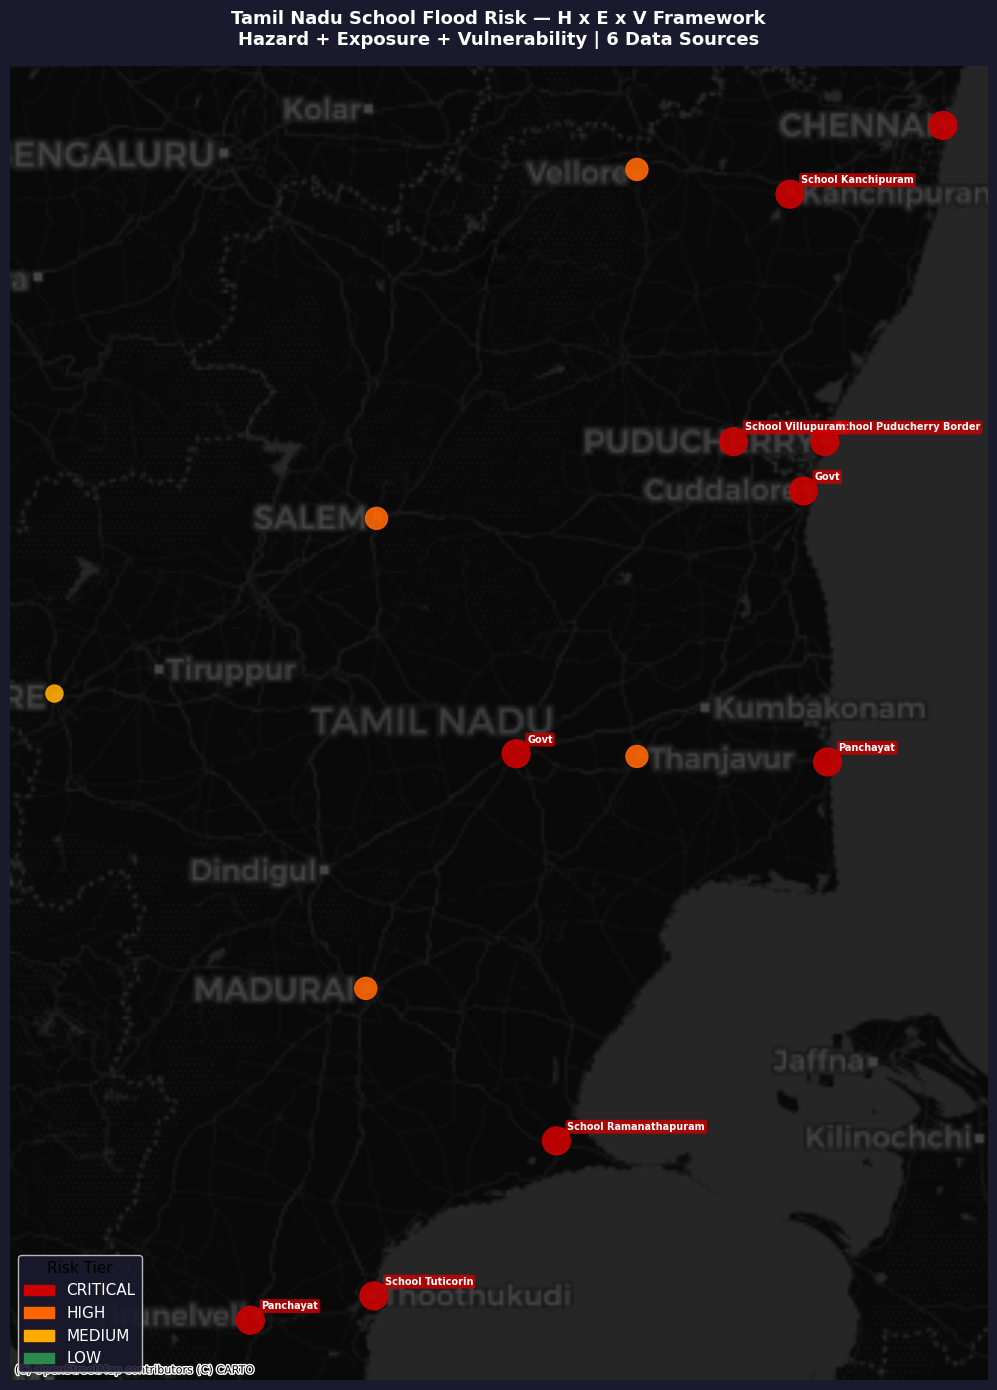

✅ Dark theme map saved!


In [11]:
#Static Kepler-style map with matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(lon, lat) for lat, lon
              in zip(df['latitude'], df['longitude'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Risk colors and sizes
color_map = {
    'CRITICAL': '#CC0000',
    'HIGH':     '#FF6600',
    'MEDIUM':   '#FFAA00',
    'LOW':      '#2D8A4E'
}
size_map = {
    'CRITICAL': 400,
    'HIGH':     250,
    'MEDIUM':   150,
    'LOW':      80
}

colors = [color_map[r] for r in gdf['hev_risk']]
sizes  = [size_map[r]  for r in gdf['hev_risk']]

fig, ax = plt.subplots(figsize=(12, 14))

# Plot points
gdf.plot(
    ax=ax,
    color=colors,
    markersize=sizes,
    alpha=0.9,
    zorder=3
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.DarkMatter,
    zoom=7
)

# Labels for CRITICAL schools
for _, row in gdf.iterrows():
    if row['hev_risk'] == 'CRITICAL':
        ax.annotate(
            row['school_name'].split(' School')[0].split('Govt ')[0].strip(),
            xy=(row.geometry.x, row.geometry.y),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=7,
            color='white',
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='#CC0000',
                alpha=0.8,
                edgecolor='none'
            )
        )

# Legend
patches = [
    mpatches.Patch(color='#CC0000', label='CRITICAL'),
    mpatches.Patch(color='#FF6600', label='HIGH'),
    mpatches.Patch(color='#FFAA00', label='MEDIUM'),
    mpatches.Patch(color='#2D8A4E', label='LOW'),
]
ax.legend(
    handles=patches,
    loc='lower left',
    fontsize=11,
    framealpha=0.9,
    facecolor='#1a1a2e',
    labelcolor='white',
    title='Risk Tier',
    title_fontsize=11
)

ax.set_axis_off()
ax.set_title(
    'Tamil Nadu School Flood Risk — H x E x V Framework\n'
    'Hazard + Exposure + Vulnerability | 6 Data Sources',
    fontsize=13,
    fontweight='bold',
    color='white',
    pad=15
)
fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(
    'tamil_nadu_kepler_style_map.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='#1a1a2e'
)
plt.show()
print('✅ Dark theme map saved!')

In [13]:
# Download all Day 11 outputs
from google.colab import files

files.download('tamil_nadu_kepler_style_map.png')
print('✅ All Day 11 files downloaded!')

print()
print('=== DAY 11 SUMMARY ===')
print('Files created:')
print('  🗺️ tamil_nadu_kepler_map.html — Interactive Kepler.gl map')
print('  🖼️ tamil_nadu_kepler_style_map.png — Dark theme 300 DPI map')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Day 11 files downloaded!

=== DAY 11 SUMMARY ===
Files created:
  🗺️ tamil_nadu_kepler_map.html — Interactive Kepler.gl map
  🖼️ tamil_nadu_kepler_style_map.png — Dark theme 300 DPI map
